# AML — Exploration Notebook

Interactive scratch space for the WRDS data pull, feature engineering, and ML model fitting.

**Pipeline flow:** §1 setup → §2/3 data → §4 features → §5 target/split → §6 fit & compare ML methods → §7 production forecast → §8 tangency optimizer (realized Σ). §9 is an appendix with model inspection and factor decompositions.

## 1. Setup & imports

In [111]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import os
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xgboost as xgb
import yfinance as yf

from pipeline import (
    CONFIG,
    wrds_connect,
    pull_crsp_msf, pull_crsp_dsf, pull_yfinance_daily,
    pull_compustat_funda, pull_ccm_link,
    merge_crsp_compustat, build_universe,
    fetch_ff5, merge_with_factors,
    build_features, FEATURE_COLS, FEATURE_DICT, feature_dictionary_df,
    get_all_feature_cols,
    make_target, train_val_test_split,
    fit_capm, fit_ff5, fit_elastic_net, fit_ridge, fit_xgboost,
    oos_r2_zero_benchmark, oos_r2_vs_historical_mean,
    rolling_oos_backtest, summarize_rolling, diebold_mariano,
    estimate_covariance, realized_covariance, tangency_portfolio,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print(f"Python: {sys.executable}")

Python: /Users/Peter.W/venvs/aml/bin/python


## Portfolio under analysis

In [112]:
portfolio = {
    "Apple":             "AAPL",
    "JPMorgan Chase":    "JPM",
    "Exxon Mobil":       "XOM",
    "Johnson & Johnson": "JNJ",
    "Procter & Gamble":  "PG",
}
ticker_to_name = {t: n for n, t in portfolio.items()}

print(f"Portfolio: {len(portfolio)} stocks")
for name, tkr in portfolio.items():
    print(f"  {tkr:<6} {name}")

Portfolio: 5 stocks
  AAPL   Apple
  JPM    JPMorgan Chase
  XOM    Exxon Mobil
  JNJ    Johnson & Johnson
  PG     Procter & Gamble


## Date configuration

In [113]:
DATA_START = "2000-01-01"   # full WRDS history (~26 years)
DATA_END   = "2026-04-30"   # latest available CRSP month-end (WRDS lag ~2 weeks)
TRAIN_END  = "2017-12-31"   # 18 years training
VAL_END    = "2019-12-31"   # 2 years validation
                            # test:  2020-01 -> 2026-04   (>6 years, includes 2025-26)

def _months(a, b):
    a, b = pd.Timestamp(a), pd.Timestamp(b)
    return (b.year - a.year) * 12 + (b.month - a.month) + 1

print(f"WRDS pull:    {DATA_START} -> {DATA_END}    ({_months(DATA_START, DATA_END)} months)")
print(f"  Train:      {DATA_START} -> {TRAIN_END}    ({_months(DATA_START, TRAIN_END)} months)")
print(f"  Validation: {TRAIN_END}+1mo -> {VAL_END}     ({_months(TRAIN_END, VAL_END) - 1} months)")
print(f"  Test:       {VAL_END}+1mo -> {DATA_END}      ({_months(VAL_END, DATA_END) - 1} months)")


WRDS pull:    2000-01-01 -> 2026-04-30    (316 months)
  Train:      2000-01-01 -> 2017-12-31    (216 months)
  Validation: 2017-12-31+1mo -> 2019-12-31     (24 months)
  Test:       2019-12-31+1mo -> 2026-04-30      (76 months)


## 2. Quick resume from cache

In [114]:
panel_path = CONFIG.cache_dir / "panel.parquet"
if panel_path.exists():
    panel = pd.read_parquet(panel_path)
    print(f"Loaded cached panel: {panel.shape}")
    print(f"  Date range in cache: {panel['date'].min().date()} -> {panel['date'].max().date()}")
else:
    print(f"No cache at {panel_path}. Run section 3 below to pull from WRDS first.")

ff5 = fetch_ff5()
print(f"FF5: {ff5.index.min().date()} -> {ff5.index.max().date()} (n={len(ff5)})")

Loaded cached panel: (1277682, 47)
  Date range in cache: 2000-01-31 -> 2024-12-31
FF5: 1963-07-31 -> 2026-03-31 (n=753)


---

## 3. Full WRDS pull (first-time setup or after changing dates)

### 3.1 Open a WRDS connection

In [115]:
conn = wrds_connect()

18:17:52 [INFO] Connecting to WRDS as cw3655...
Loading library list...
Done


### 3.2 CRSP monthly returns

In [116]:
crsp = pull_crsp_msf(conn, DATA_START, DATA_END)
print(crsp.shape); crsp.head()

18:17:54 [INFO] Pulling CRSP MSF (this can take a few minutes)...
18:18:31 [INFO]   CRSP MSF: 1,294,973 rows | 12,802 permnos | 2000-01-31 -> 2024-12-31
(1294973, 16)


,permno,date,ret,retx,prc,shrout,vol,shrcd,exchcd,ticker,comnam,siccd,dlret,dlstcd,ret_adj,mcap
0,10001,2000-01-31,-0.044118,-0.044118,8.125,2450.0,403.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,-0.044118,19906250.0
1,10001,2000-02-29,0.015385,0.015385,8.25,2450.0,222.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,0.015385,20212500.0
2,10001,2000-03-31,-0.015758,-0.030303,-8.0,2464.0,723.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,-0.015758,19712000.0
3,10001,2000-04-28,0.011719,0.011719,-8.09375,2464.0,263.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,0.011719,19943000.0
4,10001,2000-05-31,-0.023166,-0.023166,-7.90625,2464.0,221.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,-0.023166,19481000.0


### 3.3 Compustat annual fundamentals

In [117]:
comp = pull_compustat_funda(conn, DATA_START, DATA_END)
print(comp.shape); comp.head()

18:18:31 [INFO] Pulling Compustat funda...
18:18:45 [INFO]   Compustat funda: 301,462 rows | 32,852 gvkeys
(301462, 23)


,gvkey,datadate,fyear,at,lt,ceq,seq,ib,ni,oibdp,sale,revt,cogs,xsga,capx,dp,dvp,dvc,txdb,itcb,pstkrv,pstkl,pstk
0,001004,2000-05-31,1999,740.998,401.483,339.515,339.515,35.163,35.163,89.031,1024.333,1024.333,833.107,102.195,22.344,18.373,0.0,9.218,56.02,0.0,0.0,0.0,0.0
1,001004,2001-05-31,2000,701.854,361.642,340.212,340.212,18.531,18.531,64.367,874.255,874.255,713.811,96.077,13.134,18.577,0.0,9.157,55.063,0.0,0.0,0.0,0.0
2,001004,2002-05-31,2001,710.199,399.964,310.235,310.235,-58.939,-58.939,27.207,638.721,638.721,526.477,85.037,12.112,22.496,0.0,4.43,30.601,0.0,0.0,0.0,0.0
3,001004,2003-05-31,2002,686.621,391.633,294.988,294.988,-12.41,-12.41,30.745,606.337,606.337,496.747,78.845,9.93,27.172,0.0,0.797,22.601,0.0,0.0,0.0,0.0
4,001004,2004-05-31,2003,709.292,407.608,301.684,301.684,3.504,3.504,47.491,651.958,651.958,523.302,81.165,10.286,26.68,0.0,0.0,17.628,0.0,0.0,0.0,0.0


### 3.4 CCM link table + merge

In [118]:
link = pull_ccm_link(conn)
print(link.shape); link.head()

18:18:45 [INFO] Pulling CCM link table...
(33324, 6)


,gvkey,permno,linkdt,linkenddt,linktype,linkprim
0,001000,25881.0,1970-11-13,1978-06-30,LU,P
1,001001,10015.0,1983-09-20,1986-07-31,LU,P
2,001002,10023.0,1972-12-14,1973-06-05,LC,C
3,001003,10031.0,1983-12-07,1989-08-16,LU,C
4,001004,54594.0,1972-04-24,2026-05-10,LU,P


In [119]:
panel = merge_crsp_compustat(crsp, comp, link)
panel = build_universe(panel, kind="top1000_mcap")
print(panel.shape); panel.head()

18:18:48 [INFO]   Merged panel: 1,277,682 rows
(1277682, 47)


,permno,date,ret,retx,prc,shrout,vol,shrcd,exchcd,ticker,comnam,siccd,dlret,dlstcd,ret_adj,mcap,gvkey,linkdt,linkenddt,linktype,...,ib,ni,oibdp,sale,revt,cogs,xsga,capx,dp,dvp,dvc,txdb,itcb,pstkrv,pstkl,pstk,available_date,mcap_lag1,mcap_rank,in_universe
0,10001,2000-01-31,-0.044118,-0.044118,8.125,2450.0,403.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,-0.044118,19906250.0,012994,1986-01-09,2017-08-31,LC,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,<NA>,<NA>
12918,10001,2000-02-29,0.015385,0.015385,8.25,2450.0,222.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,0.015385,20212500.0,012994,1986-01-09,2017-08-31,LC,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,19906250.0,5566.0,False
17439,10001,2000-03-31,-0.015758,-0.030303,-8.0,2464.0,723.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,-0.015758,19712000.0,012994,1986-01-09,2017-08-31,LC,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,20212500.0,5628.0,False
19533,10001,2000-04-28,0.011719,0.011719,-8.09375,2464.0,263.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,0.011719,19943000.0,012994,1986-01-09,2017-08-31,LC,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,19712000.0,5640.0,False
32377,10001,2000-05-31,-0.023166,-0.023166,-7.90625,2464.0,221.0,11,3,EWST,ENERGY WEST INC,4920,<NA>,<NA>,-0.023166,19481000.0,012994,1986-01-09,2017-08-31,LC,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,19943000.0,5527.0,False


### 3.5 Inspect the panel

In [120]:
miss = panel.isna().mean().sort_values(ascending=False)
miss[miss > 0]

dlret             0.999141
dlstcd            0.996192
xsga              0.222947
itcb              0.208278
txdb              0.170656
capx              0.123140
dp                0.106138
oibdp             0.097643
dvc               0.095487
lt                0.094953
dvp               0.094840
ib                0.094840
ni                0.094840
cogs              0.094840
revt              0.094826
sale              0.094826
pstkl             0.094089
pstkrv            0.093724
pstk              0.093584
ceq               0.093166
at                0.092861
seq               0.092861
fyear             0.089518
datadate          0.089135
available_date    0.089135
mcap_lag1         0.009926
mcap_rank         0.009926
in_universe       0.009926
ret               0.004896
retx              0.004896
ret_adj           0.004895
prc               0.000045
mcap              0.000045
vol               0.000006
dtype: float64

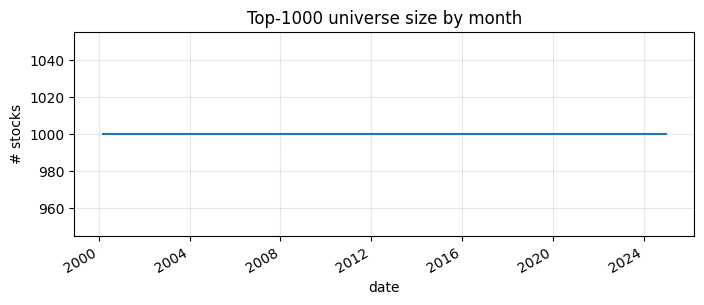

In [121]:
uni_size = panel[panel["in_universe"]].groupby("date")["permno"].nunique()
ax = uni_size.plot(figsize=(8, 3), title="Top-1000 universe size by month")
ax.set_ylabel("# stocks"); ax.grid(alpha=0.3)

### 3.6 Cache the panel

**Don't close `conn`** — §8 needs it for the daily-data pull.

In [122]:
CONFIG.cache_dir.mkdir(parents=True, exist_ok=True)
panel.to_parquet(CONFIG.cache_dir / "panel.parquet")
print(f"Cached -> {CONFIG.cache_dir / 'panel.parquet'}")

Cached -> cache/panel.parquet


---

## 4. Feature engineering

### 4.0 Feature dictionary

In [123]:
import importlib, pipeline
importlib.reload(pipeline)
from pipeline import (
    feature_dictionary_df, FEATURE_DICT, FEATURE_COLS,
    build_features, get_all_feature_cols,
    pull_crsp_dsf, pull_yfinance_daily, realized_covariance,
    merge_with_factors,
    make_target, train_val_test_split,
    fit_capm, fit_ff5, fit_elastic_net, fit_ridge, fit_xgboost,
    oos_r2_zero_benchmark, oos_r2_vs_historical_mean,
    rolling_oos_backtest, summarize_rolling, diebold_mariano,
    tangency_portfolio,
)

feat_dict_df = feature_dictionary_df()
feat_dict_df

,feature,name,category,formula,source,intuition,expected_sign,reference
0,size,Market capitalization (log),price,log(|prc| × shrout),CRSP,Smaller firms tend to earn higher average retu...,−,Banz (1981); Fama-French SMB (1993)
1,mom_1,Short-term reversal (1-month),price,ret_{t},CRSP,Last month's return reverses next month — liqu...,−,Jegadeesh (1990)
2,mom_12_2,"Momentum (12-2, skip-month)",price,"cumret(ret_{t-12}, …, ret_{t-2})",CRSP,Stocks that outperformed over past year (exclu...,+,Jegadeesh-Titman (1993); Carhart (1997)
3,mom_36_13,Long-term reversal (36-13),price,"cumret(ret_{t-36}, …, ret_{t-13})",CRSP,Past long-horizon winners tend to underperform...,−,DeBondt-Thaler (1985)
4,vol_12,Return volatility (12-month),price,"std(ret_{t-12}, …, ret_{t-1})",CRSP,Low-volatility stocks earn higher risk-adjuste...,−,"Ang, Hodrick, Xing, Zhang (2006)"
5,turnover,Share turnover,price,vol_{t} / shrout_{t},CRSP,Liquidity / attention proxy. Higher turnover a...,−,"Datar, Naik, Radcliffe (1998)"
6,mom_6_2,Medium-term momentum (6-2),price,"cumret(ret_{t-6}, …, ret_{t-2})",CRSP,Shorter-horizon momentum complements 12-2 mome...,+,Jegadeesh-Titman (1993)
7,maxret,Maximum monthly return (12-mo),price,"max(ret_{t-12}, …, ret_{t-1})",CRSP,Lottery-like stocks (high max return) underper...,−,"Bali, Cakici, Whitelaw (2011)"
8,nsi,Net share issuance (12-mo),price,log(shrout_{t} / shrout_{t-12}),CRSP,Firms that issue shares (positive nsi) tend to...,−,Pontiff-Woodgate (2008); Daniel-Titman (2006)
9,beta,CAPM beta (36-mo rolling),price,"Cov(r_i, Mkt-RF) / Var(Mkt-RF), 36-month rolli...",CRSP + Ken French,High-beta stocks have lower risk-adjusted retu...,−,Frazzini-Pedersen (2014); Ang-Hodrick-Xing-Zha...


In [124]:
feat_dict_df.to_csv("feature_dictionary.csv", index=False)
print("Saved -> feature_dictionary.csv")

Saved -> feature_dictionary.csv


### 4.1 Build features

In [125]:
features = build_features(panel, ff5=ff5, with_industry=True)
print(f"Features panel shape: {features.shape}")

ALL_COLS = get_all_feature_cols(features)
print(f"Total feature columns: {len(ALL_COLS)}")
print(f"  Firm characteristics ({len(FEATURE_COLS)}): {FEATURE_COLS}")
industry_cols = [c for c in ALL_COLS if c.startswith('sic_')]
print(f"  Industry dummies ({len(industry_cols)}): {industry_cols[:8]}...")

18:19:10 [INFO]   build_features: added 80 SIC2 industry dummies
18:19:10 [INFO] Features built: 17 firm chars × 1,277,682 rows
18:19:10 [INFO]   Firm-char columns: ['size', 'mom_1', 'mom_12_2', 'mom_36_13', 'vol_12', 'turnover', 'mom_6_2', 'maxret', 'nsi', 'beta', 'age', 'bm', 'ep', 'profit', 'leverage', 'invest', 'ind_mom']
Features panel shape: (1277682, 145)
Total feature columns: 97
  Firm characteristics (17): ['size', 'mom_1', 'mom_12_2', 'mom_36_13', 'vol_12', 'turnover', 'mom_6_2', 'maxret', 'nsi', 'beta', 'age', 'bm', 'ep', 'profit', 'leverage', 'invest', 'ind_mom']
  Industry dummies (80): ['sic_0', 'sic_1', 'sic_10', 'sic_11', 'sic_12', 'sic_13', 'sic_14', 'sic_15']...


### 4.2 Sanity checks

In [126]:
features[FEATURE_COLS].describe().T[["min", "max", "mean", "std"]].round(3)

,min,max,mean,std
size,-0.999692,1.0,0.000235,0.577337
mom_1,-0.999691,1.0,0.000235,0.575935
mom_12_2,-0.999645,1.0,0.000225,0.543393
mom_36_13,-0.999544,1.0,0.000207,0.481437
vol_12,-0.999649,1.0,0.000226,0.543915
turnover,-0.999693,1.0,0.000235,0.577349
mom_6_2,-0.999673,1.0,0.00023,0.560253
maxret,-0.999649,1.0,0.000226,0.543915
nsi,-0.999645,1.0,0.000225,0.543371
beta,-0.999649,1.0,0.000226,0.54481


In [127]:
features[FEATURE_COLS].corr().round(2)

,size,mom_1,mom_12_2,mom_36_13,vol_12,turnover,mom_6_2,maxret,nsi,beta,age,bm,ep,profit,leverage,invest,ind_mom
size,1.00,0.12,0.27,0.27,-0.36,0.42,0.21,-0.28,-0.10,0.03,0.20,-0.32,0.30,0.43,0.09,0.15,0.09
mom_1,0.12,1.00,0.05,0.03,-0.06,0.03,0.04,0.02,-0.03,-0.02,0.04,-0.09,0.04,0.07,0.02,0.01,0.02
mom_12_2,0.27,0.05,1.00,0.04,-0.20,0.03,0.62,0.04,0.03,-0.10,0.09,-0.29,0.11,0.17,0.07,0.02,0.29
mom_36_13,0.27,0.03,0.04,1.00,-0.26,0.02,0.04,-0.23,-0.01,-0.12,0.08,-0.19,0.33,0.30,0.02,0.31,0.01
vol_12,-0.36,-0.06,-0.20,-0.26,1.00,0.26,-0.13,0.88,0.29,0.48,-0.21,-0.03,-0.45,-0.30,-0.21,-0.08,-0.09
turnover,0.42,0.03,0.03,0.02,0.26,1.00,0.01,0.21,0.10,0.30,0.01,-0.23,-0.07,0.14,-0.09,0.07,0.01
mom_6_2,0.21,0.04,0.62,0.04,-0.13,0.01,1.00,0.05,-0.02,-0.06,0.07,-0.20,0.06,0.11,0.05,-0.01,0.19
maxret,-0.28,0.02,0.04,-0.23,0.88,0.21,0.05,1.00,0.26,0.41,-0.16,-0.11,-0.40,-0.24,-0.17,-0.08,-0.02
nsi,-0.10,-0.03,0.03,-0.01,0.29,0.10,-0.02,0.26,1.00,0.12,-0.17,-0.18,-0.26,-0.23,-0.07,0.12,-0.02
beta,0.03,-0.02,-0.10,-0.12,0.48,0.30,-0.06,0.41,0.12,1.00,-0.04,-0.05,-0.20,-0.07,-0.12,-0.05,-0.05


---

## 5. Build target + train/val/test split

In [128]:
fwt = make_target(features, kind="excess_rf", rf=ff5["RF"])
print(f"Panel with target: {fwt.shape}")
print(f"Non-null y: {fwt['y'].notna().sum():,}")
print(f"\nRaw y summary:")
print(fwt[["y"]].dropna().describe().T.round(4))

# Winsorize y at ±50%/month — handles thinly-traded extreme outliers
WINSOR_BOUND = 0.50
n_clipped = ((fwt["y"] < -WINSOR_BOUND) | (fwt["y"] > WINSOR_BOUND)).sum()
fwt["y"] = fwt["y"].clip(-WINSOR_BOUND, WINSOR_BOUND)
print(f"\nWinsorized y at ±{WINSOR_BOUND*100:.0f}% — {n_clipped} observations clipped")

Panel with target: (1277682, 146)
Non-null y: 1,264,678

Raw y summary:
       count    mean     std     min     25%  50%     75%      max
y  1264678.0  0.0072  0.2044 -1.0014 -0.0725  0.0  0.0698  26.5794

Winsorized y at ±50% — 27803 observations clipped


In [129]:
X_tr, y_tr, X_va, y_va, X_te, y_te = train_val_test_split(
    fwt,
    train_end=TRAIN_END,
    val_end=VAL_END,
    test_end=DATA_END,
    feature_cols=ALL_COLS,
)
print(f"Train: X={X_tr.shape}, y={y_tr.shape}, mean(y)={y_tr.mean():.4f}, std(y)={y_tr.std():.4f}")
print(f"Val:   X={X_va.shape}, y={y_va.shape}, mean(y)={y_va.mean():.4f}, std(y)={y_va.std():.4f}")
print(f"Test:  X={X_te.shape}, y={y_te.shape}, mean(y)={y_te.mean():.4f}, std(y)={y_te.std():.4f}")

18:19:20 [INFO] Split sizes: train=214,127, val=23,922, test=58,850 (features=97)
Train: X=(214127, 97), y=(214127,), mean(y)=0.0065, std(y)=0.1071
Val:   X=(23922, 97), y=(23922,), mean(y)=0.0041, std(y)=0.0938
Test:  X=(58850, 97), y=(58850,), mean(y)=0.0077, std(y)=0.1157


---

## 6. Fit ML models — three to compare

1. **ElasticNet** — linear with mixed L1/L2 penalty.
2. **Ridge** — pure L2; cannot zero out coefs (all features stay active).
3. **XGBoost** — gradient-boosted trees; captures nonlinear interactions.

Fit all three, compare OOS R² in §6.4, pick the best in §6.5.

### 6.1 ElasticNet

In [130]:
model_enet = fit_elastic_net(X_tr, y_tr)
print(f"\nChosen alpha    = {model_enet.alpha_:.4g}")
print(f"Chosen l1_ratio = {model_enet.l1_ratio_:.2f}")
print(f"Nonzero coefs   = {int((model_enet.coef_ != 0).sum())}/{len(ALL_COLS)}")

18:19:22 [INFO] Fitting ElasticNet on 214,127 obs × 97 features...
18:19:25 [INFO]   Chosen: alpha=0.01238, l1_ratio=0.10, nonzero coefs=0

Chosen alpha    = 0.01238
Chosen l1_ratio = 0.10
Nonzero coefs   = 0/97


### 6.2 Ridge

In [131]:
model_ridge = fit_ridge(X_tr, y_tr)
print(f"\nChosen alpha   = {model_ridge.alpha_:.4g}")
print(f"|coef| max     = {np.abs(model_ridge.coef_).max():.4g}")
print(f"|coef| mean    = {np.abs(model_ridge.coef_).mean():.4g}")
print(f"Nonzero coefs  = {int((model_ridge.coef_ != 0).sum())}/{len(ALL_COLS)} (Ridge keeps all)")

18:19:25 [INFO] Fitting Ridge on 214,127 obs × 97 features...
18:19:43 [INFO]   Chosen alpha=100, |coef|_max=0.02206, |coef|_min nonzero=2.62e-06

Chosen alpha   = 100
|coef| max     = 0.02206
|coef| mean    = 0.002735
Nonzero coefs  = 89/97 (Ridge keeps all)


### 6.3 XGBoost

Gradient-boosted trees with early stopping on the validation set. Requires `pip install xgboost` (in the `aml` venv) if not already installed.

In [132]:
model_xgb = fit_xgboost(
    X_tr, y_tr,
    X_val=X_va, y_val=y_va,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
)
print(f"\nBest iteration: {model_xgb.best_iteration} / {model_xgb.n_estimators}")

18:19:43 [INFO] Fitting XGBoost on 214,127 obs × 97 features (max_estimators=500, max_depth=4, early_stopping=20)...
18:19:44 [INFO]   Best iteration: 0 of 500

Best iteration: 0 / 500


In [133]:
# Top-15 feature importances (gain-based)
imp = pd.Series(model_xgb.feature_importances_, index=ALL_COLS).sort_values(ascending=False)
print("Top-15 features by XGBoost gain importance:\n")
print(imp.head(15).round(4))

Top-15 features by XGBoost gain importance:

age          0.1929
turnover     0.0875
profit       0.0868
vol_12       0.0797
ep           0.0681
mom_36_13    0.0642
beta         0.0540
sic_73       0.0524
sic_13       0.0500
mom_6_2      0.0488
mom_12_2     0.0389
sic_48       0.0363
mom_1        0.0213
sic_28       0.0205
ind_mom      0.0205
dtype: float32


### 6.4 Side-by-side comparison

Headline metric is **OOS R² (zero benchmark)** — GKX-comparable. Historical-mean version included for reference.

In [134]:
results = []
model_dict = {"ElasticNet": model_enet, "Ridge": model_ridge, "XGBoost": model_xgb}
for name, model in model_dict.items():
    y_pred_m = model.predict(X_te)
    r2_zero  = oos_r2_zero_benchmark(y_te, y_pred_m)
    y_hist   = np.full_like(y_te, y_tr.mean())
    r2_hist  = oos_r2_vs_historical_mean(
        pd.Series(y_te), pd.Series(y_pred_m), pd.Series(y_hist)
    )
    results.append({
        "model":            name,
        "OOS R² (zero, %)": round(r2_zero * 100, 4),
        "OOS R² (hist, %)": round(r2_hist * 100, 4),
    })
comparison = pd.DataFrame(results).set_index("model")
print("Model comparison (test set OOS R²):\n")
print(comparison)

Model comparison (test set OOS R²):

            OOS R² (zero, %)  OOS R² (hist, %)
model                                         
ElasticNet            0.4345            0.0000
Ridge                 0.2907           -0.1445
XGBoost               0.4425            0.0081


### 6.5 Pick the best ML method

Auto-select the model with highest zero-benchmark OOS R². Override manually if you prefer one for methodological reasons (e.g., reviewer asks for the linear ML representative — pick Ridge).

The chosen model feeds the production forecast (§7) and the tangency optimizer (§8).

In [135]:
# Single-split best — will be revisited in §6.6 walk-forward
best_name_single = comparison["OOS R² (zero, %)"].idxmax()
print(f"Single-split best: {best_name_single}")
print(f"  OOS R² (zero): {comparison.loc[best_name_single, 'OOS R² (zero, %)']:.4f}%")
print(f"  OOS R² (hist): {comparison.loc[best_name_single, 'OOS R² (hist, %)']:.4f}%")


Single-split best: XGBoost
  OOS R² (zero): 0.4425%
  OOS R² (hist): 0.0081%


### 6.6 Walk-forward backtest

Annual refit. For each test year *y*: train on years [y − train_years − val_years, y − val_years − 1], validate on years [y − val_years, y − 1] (used for XGBoost early stopping), predict each month of *y*. Walk forward, repeat.

**With 5 years of data** (2020–2024), `train_years=2, val_years=1` gives test years **2023 and 2024** — only 2 OOS observations. Tight but workable; the *pooled* R² across both years is the headline. With 10+ years you'd get 5+ test years and a richer comparison.

**Pooled R²** is the GKX-style headline; **per-year R²** and **hit rate** show whether the result is robust or driven by one lucky year.

In [136]:
TRAIN_YEARS = 10
VAL_YEARS   = 1
BACKTEST_TEST_START = "2020-01-01"   # 5-year test window
BACKTEST_TEST_END   = DATA_END

rolling_results = {}
for name, fit_fn in [
    ("ElasticNet", fit_elastic_net),
    ("Ridge",      fit_ridge),
    ("XGBoost",    fit_xgboost),
]:
    print(f"\n=== {name} ===")
    rolling_results[name] = rolling_oos_backtest(
        fwt, ALL_COLS, fit_fn,
        train_years=TRAIN_YEARS,
        val_years=VAL_YEARS,
        test_start=BACKTEST_TEST_START,
        test_end=BACKTEST_TEST_END,
    )



=== ElasticNet ===
18:19:47 [INFO] Rolling backtest: fit_elastic_net | train_years=10, val_years=1, test years 2020-2026 (7 years)
18:19:48 [INFO] Fitting ElasticNet on 119,585 obs × 97 features...
18:19:48 [INFO]   Chosen: alpha=0.007695, l1_ratio=0.10, nonzero coefs=0
18:19:48 [INFO]   Year 2020: train=119,585, val=11,966, test=11,967, OOS R²=+1.974%
18:19:49 [INFO] Fitting ElasticNet on 119,576 obs × 97 features...
18:19:49 [INFO]   Chosen: alpha=0.006669, l1_ratio=0.10, nonzero coefs=0
18:19:49 [INFO]   Year 2021: train=119,576, val=11,967, test=11,973, OOS R²=+0.133%
18:19:49 [INFO] Fitting ElasticNet on 119,583 obs × 97 features...
18:19:50 [INFO]   Chosen: alpha=0.009052, l1_ratio=0.10, nonzero coefs=0
18:19:50 [INFO]   Year 2022: train=119,583, val=11,973, test=11,964, OOS R²=-1.143%
18:19:50 [INFO] Fitting ElasticNet on 119,605 obs × 97 features...
18:19:51 [INFO]   Chosen: alpha=0.006455, l1_ratio=0.10, nonzero coefs=0
18:19:51 [INFO]   Year 2023: train=119,605, val=11,964, 

In [137]:
rolling_summary = pd.DataFrame([
    {
        "model":         name,
        "pooled_R² (%)":   round(s["pooled_r2_zero"] * 100, 4),
        "hit_rate (%)":  round(s["hit_rate"] * 100, 1),
        "n_test_years":  s["n_test_years"],
        "n_obs":         s["n_observations"],
    }
    for name, s in [(n, summarize_rolling(r)) for n, r in rolling_results.items()]
]).set_index("model")
print("Walk-forward backtest summary:\n")
print(rolling_summary)


Walk-forward backtest summary:

            pooled_R² (%)  hit_rate (%)  n_test_years  n_obs
model                                                       
ElasticNet         0.4337          60.0             5  58850
Ridge              0.1390          40.0             5  58850
XGBoost            0.4994          80.0             5  58850


In [138]:
yearly = pd.DataFrame({
    name: summarize_rolling(r)["yearly_r2"] * 100
    for name, r in rolling_results.items()
}).round(4)
yearly.index.name = "test_year"
print("Per-year OOS R² (%, zero benchmark):\n")
print(yearly)


Per-year OOS R² (%, zero benchmark):

           ElasticNet   Ridge  XGBoost
test_year                             
2020           1.9742  1.9390   2.0153
2021           0.1329 -0.3189   0.1502
2022          -1.1433 -2.0518  -1.3831
2023          -0.4910 -0.3428   0.4003
2024           0.8769  0.6425   0.5896


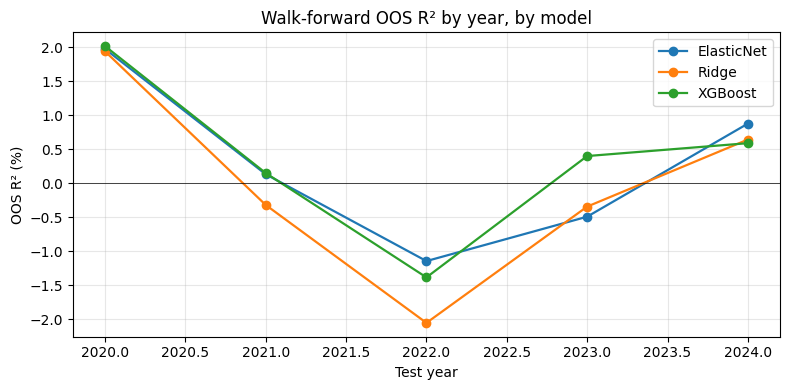

In [139]:
fig, ax = plt.subplots(figsize=(8, 4))
yearly.plot(marker="o", ax=ax, linewidth=1.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("OOS R² (%)")
ax.set_xlabel("Test year")
ax.set_title("Walk-forward OOS R² by year, by model")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### 6.7 Diebold-Mariano test — best vs others

Tests whether the difference in pooled squared error is statistically significant. Negative t-stat → first model has smaller errors.

**Caveat:** with only 2 test years, statistical power is modest. DM is more meaningful with 5+ test years.

In [140]:
best = rolling_summary["pooled_R² (%)"].idxmax()
others = [m for m in rolling_summary.index if m != best]

for other in others:
    aligned = rolling_results[best].merge(
        rolling_results[other][["date", "permno", "y_pred"]],
        on=["date", "permno"], suffixes=("", "_b"),
    )
    dm = diebold_mariano(
        aligned["y"].values,
        aligned["y_pred"].values,
        aligned["y_pred_b"].values,
    )
    print(f"{best} vs {other}:")
    print(f"  n={dm['n']:,}  mean(SSE_diff)={dm['mean_sse_diff']:.6f}  "
          f"t={dm['t_stat']:.3f}  p={dm['p_value']:.4f}")
    if dm['p_value'] < 0.10:
        better = best if dm['mean_sse_diff'] < 0 else other
        print(f"  ⇒ {better} significantly better (p<0.10)")
    else:
        print(f"  ⇒ no significant difference (p>=0.10)")
    print()


XGBoost vs ElasticNet:
  n=58,850  mean(SSE_diff)=-0.000009  t=-2.104  p=0.0354
  ⇒ XGBoost significantly better (p<0.10)

XGBoost vs Ridge:
  n=58,850  mean(SSE_diff)=-0.000048  t=-7.802  p=0.0000
  ⇒ XGBoost significantly better (p<0.10)



### 6.8 Final model selection

Walk-forward pooled R² is the more reliable signal. If single-split and walk-forward agree, easy. If they disagree, trust walk-forward.

In [141]:
best_name_rolling = rolling_summary["pooled_R² (%)"].idxmax()

print(f"Single-split (§6.5) picks: {best_name_single}")
print(f"Walk-forward (§6.6) picks: {best_name_rolling}")

# Default: trust walk-forward. Override below if you want.
chosen_name  = best_name_rolling
chosen_model = model_dict[chosen_name]

# Manual override:
# chosen_name = "ElasticNet"
# chosen_model = model_dict[chosen_name]

print(f"\nFinal choice for §7-8: {chosen_name}")
print(f"  Walk-forward pooled R²: {rolling_summary.loc[chosen_name, 'pooled_R² (%)']:.4f}%")
print(f"  Walk-forward hit rate:  {rolling_summary.loc[chosen_name, 'hit_rate (%)']:.1f}%")
print(f"  Single-split R²:        {comparison.loc[chosen_name, 'OOS R² (zero, %)']:.4f}%")


Single-split (§6.5) picks: XGBoost
Walk-forward (§6.6) picks: XGBoost

Final choice for §7-8: XGBoost
  Walk-forward pooled R²: 0.4994%
  Walk-forward hit rate:  80.0%
  Single-split R²:        0.4425%


---

## 7. Production forecast

Refit the chosen model class on the **full available sample** (train + validation + test) and forecast next-month excess returns for the portfolio. No holdout — for live use, you want every drop of training data.

### 7.1 Train production model on all data

In [142]:
fit_df = fwt.dropna(subset=["y"]).query("in_universe").sort_values(["date", "permno"])
X_all = fit_df[ALL_COLS].values
y_all = fit_df["y"].values
print(f"Production training set: {X_all.shape[0]:,} obs × {X_all.shape[1]} features")

if chosen_name == "ElasticNet":
    model_prod = fit_elastic_net(X_all, y_all)
    print(f"\nProduction ElasticNet: alpha={model_prod.alpha_:.4g}, l1_ratio={model_prod.l1_ratio_:.2f}")
elif chosen_name == "Ridge":
    model_prod = fit_ridge(X_all, y_all)
    print(f"\nProduction Ridge: alpha={model_prod.alpha_:.4g}")
elif chosen_name == "XGBoost":
    n_best = getattr(model_xgb, "best_iteration", 500) or 500
    model_prod = fit_xgboost(
        X_all, y_all,
        n_estimators=n_best,
        max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
    )
    print(f"\nProduction XGBoost: trained {n_best} trees (best from validation)")
else:
    raise ValueError(f"Unknown chosen_name: {chosen_name}")

Production training set: 296,899 obs × 97 features
18:20:52 [INFO] Fitting XGBoost on 296,899 obs × 97 features (estimators=500, no early stopping)...

Production XGBoost: trained 500 trees (best from validation)


### 7.2 Forecast next month for the portfolio

In [143]:
def forecast_for_subset(tickers, model, features_df, feature_cols, name_lookup=None):
    """Most-recent feature snapshot per ticker -> predicted next-month excess return."""
    latest = (
        features_df[features_df["in_universe"]]
          .sort_values(["ticker", "date"])
          .groupby("ticker")
          .tail(1)
    )
    sub = latest[latest["ticker"].isin(tickers)].set_index("ticker").reindex(tickers)
    missing = sub[sub[feature_cols].isna().any(axis=1)].index.tolist()
    if missing:
        print(f"Warning: missing features for {missing} — μ̂ will be unreliable")
    sub["mu_hat"] = model.predict(sub[feature_cols].fillna(0).values)
    sub["as_of"]  = sub["date"]
    if name_lookup:
        sub.insert(0, "company", sub.index.map(name_lookup))
    return sub[(["company"] if name_lookup else []) + ["as_of", "mu_hat"] + FEATURE_COLS]

fcast = forecast_for_subset(
    list(portfolio.values()),
    model_prod,
    features,
    feature_cols=ALL_COLS,
    name_lookup=ticker_to_name,
)
print(f"μ̂ forecast (using {chosen_name}, excess of risk-free rate, monthly horizon):")
print(fcast[["company", "as_of", "mu_hat"]].to_string())

μ̂ forecast (using XGBoost, excess of risk-free rate, monthly horizon):
                  company      as_of    mu_hat
ticker                                        
AAPL                Apple 2024-12-31  0.004431
JPM        JPMorgan Chase 2024-12-31  0.002526
XOM           Exxon Mobil 2024-12-31  0.007890
JNJ     Johnson & Johnson 2024-12-31  0.003151
PG       Procter & Gamble 2024-12-31  0.005297


---

## 8. Tangency portfolio with realized covariance

Closed-form mean-variance optimal weights:

$$w^\star \;\propto\; \hat\Sigma^{-1} \, \hat\mu, \qquad \sum_i w_i^\star = 1$$

$\hat\mu$ from §7.2 (chosen ML model). $\hat\Sigma$ from realized covariance over past ~60 trading days of daily returns (Andersen-Bollerslev-Diebold-Labys 2003).

### 8.1 Pull daily returns for the portfolio stocks

In [144]:
# Daily returns from yfinance (no WRDS login needed)
port_tickers = list(portfolio.values())

daily_buffer_start = (pd.Timestamp(DATA_END) - pd.DateOffset(months=12)).strftime("%Y-%m-%d")
daily_wide = pull_yfinance_daily(port_tickers, daily_buffer_start, DATA_END)
print(f"Daily returns shape: {daily_wide.shape} (dates × tickers)")
daily_wide.tail()


18:20:57 [INFO] Pulling yfinance daily for 5 tickers (2025-04-30 -> 2026-04-30)...
18:20:57 [INFO]   yfinance: 250 dates × 5 tickers
Daily returns shape: (250, 5) (dates × tickers)


Ticker,AAPL,JPM,XOM,JNJ,PG
date,,,,,
2026-04-23,0.000952,-0.004249,0.006890,0.020124,0.020021
2026-04-24,-0.008668,-0.010940,-0.010762,-0.013657,0.024609
2026-04-27,-0.012728,0.010867,-0.004835,-0.009495,0.001485
2026-04-28,0.011584,-0.000578,0.015993,0.010872,0.005189
2026-04-29,-0.001995,-0.007064,0.027298,-0.001932,-0.018167


### 8.2 Realized covariance from past 60 trading days

In [145]:
Sigma = realized_covariance(daily_wide, window_days=60, horizon="monthly")
print("Realized covariance Σ (monthly horizon):")
print(Sigma.round(5))

18:20:57 [INFO] Realized covariance: 60 daily obs × 5 assets | horizon=monthly
Realized covariance Σ (monthly horizon):
Ticker     AAPL      JPM      XOM      JNJ       PG
Ticker                                             
AAPL    0.00524  0.00207 -0.00089  0.00020  0.00080
JPM     0.00207  0.00496 -0.00105 -0.00026 -0.00018
XOM    -0.00089 -0.00105  0.00752  0.00019 -0.00092
JNJ     0.00020 -0.00026  0.00019  0.00221  0.00150
PG      0.00080 -0.00018 -0.00092  0.00150  0.00387


In [146]:
vols = pd.Series(np.sqrt(np.diag(Sigma.values)), index=Sigma.index, name="monthly_vol")
print("Monthly volatility (annualized in parens):\n")
for t, v in vols.items():
    print(f"  {t:<6} {v*100:.2f}%   (annualized: {v*np.sqrt(12)*100:.1f}%)")

Monthly volatility (annualized in parens):

  AAPL   7.24%   (annualized: 25.1%)
  JPM    7.04%   (annualized: 24.4%)
  XOM    8.67%   (annualized: 30.0%)
  JNJ    4.70%   (annualized: 16.3%)
  PG     6.22%   (annualized: 21.6%)


In [147]:
stds = np.sqrt(np.diag(Sigma.values))
corr = Sigma.values / np.outer(stds, stds)
pd.DataFrame(corr, index=Sigma.index, columns=Sigma.columns).round(2)

Ticker,AAPL,JPM,XOM,JNJ,PG
Ticker,,,,,
AAPL,1.00,0.41,-0.14,0.06,0.18
JPM,0.41,1.00,-0.17,-0.08,-0.04
XOM,-0.14,-0.17,1.00,0.05,-0.17
JNJ,0.06,-0.08,0.05,1.00,0.51
PG,0.18,-0.04,-0.17,0.51,1.00


### 8.3 Compute tangency portfolio weights

In [148]:
mu_hat = fcast["mu_hat"].reindex(port_tickers).values
Sigma_ordered = Sigma.loc[port_tickers, port_tickers].values
w_star = tangency_portfolio(mu_hat, Sigma_ordered, rf=0.0)

result = pd.DataFrame({
    "company":  [ticker_to_name[t] for t in port_tickers],
    "ticker":   port_tickers,
    "mu_hat":   mu_hat,
    "weight":   w_star,
})
print(f"Tangency portfolio (μ̂ from {chosen_name}, Σ̂ from realized covariance):")
print(result.to_string(index=False))
print(f"\nSum of weights:  {w_star.sum():.4f}")
print(f"Long exposure:   {w_star[w_star > 0].sum():.4f}")
print(f"Short exposure:  {w_star[w_star < 0].sum():.4f}")

Tangency portfolio (μ̂ from XGBoost, Σ̂ from realized covariance):
          company ticker   mu_hat   weight
            Apple   AAPL 0.004431 0.135754
   JPMorgan Chase    JPM 0.002526 0.141593
      Exxon Mobil    XOM 0.007890 0.313071
Johnson & Johnson    JNJ 0.003151 0.075056
 Procter & Gamble     PG 0.005297 0.334526

Sum of weights:  1.0000
Long exposure:   1.0000
Short exposure:  0.0000


In [149]:
exp_ret = float(w_star @ mu_hat)
port_var = float(w_star @ Sigma_ordered @ w_star)
port_vol = float(np.sqrt(port_var))
sharpe_m = exp_ret / port_vol if port_vol > 0 else np.nan

print(f"Expected monthly excess return:  {exp_ret*100:.3f}%")
print(f"Expected monthly volatility:     {port_vol*100:.3f}%")
print(f"Sharpe ratio (monthly):          {sharpe_m:.3f}")
print(f"Sharpe ratio (annualized × √12): {sharpe_m * np.sqrt(12):.3f}")

Expected monthly excess return:  0.544%
Expected monthly volatility:     3.514%
Sharpe ratio (monthly):          0.155
Sharpe ratio (annualized × √12): 0.536


---

## 9. Walk-forward backtest of the strategy vs. S&P 500

End-to-end performance test. For each month in the OOS window:
1. Take ML predictions $\hat\mu$ from §6.6 rolling backtest (chosen model).
2. Estimate $\hat\Sigma$ from the prior 60 trading days of yfinance daily returns.
3. Compute tangency weights $w^\star \propto \hat\Sigma^{-1}\hat\mu$.
4. Apply weights to the realized next-month excess return.
5. Compare cumulative wealth path against SPY (S&P 500 ETF) buy-and-hold.

This is the proper way to evaluate a portfolio strategy — model and Σ both refit at every rebalance, no look-ahead bias, full apples-to-apples vs the benchmark.

### 9.1 Pull daily returns for portfolio + SPY

In [150]:
# Backtest needs daily history covering [test_start − 60 trading days, test_end]
backtest_start = pd.Timestamp(BACKTEST_TEST_START)
backtest_end   = pd.Timestamp(BACKTEST_TEST_END)
buffer_start   = (backtest_start - pd.DateOffset(months=6)).strftime("%Y-%m-%d")

bt_tickers = port_tickers + ["SPY"]
daily_bt = pull_yfinance_daily(bt_tickers, buffer_start, backtest_end.strftime("%Y-%m-%d"))
print(f"Daily backtest data: {daily_bt.shape} (dates × tickers)")
daily_bt.tail()


18:20:57 [INFO] Pulling yfinance daily for 6 tickers (2019-07-01 -> 2026-04-30)...
18:20:58 [INFO]   yfinance: 1716 dates × 6 tickers
Daily backtest data: (1716, 6) (dates × tickers)


Ticker,AAPL,JPM,XOM,JNJ,PG,SPY
date,,,,,,
2026-04-23,0.000952,-0.004249,0.006890,0.020124,0.020021,-0.003881
2026-04-24,-0.008668,-0.010940,-0.010762,-0.013657,0.024609,0.007749
2026-04-27,-0.012728,0.010867,-0.004835,-0.009495,0.001485,0.001723
2026-04-28,0.011584,-0.000578,0.015993,0.010872,0.005189,-0.004866
2026-04-29,-0.001995,-0.007064,0.027298,-0.001932,-0.018167,-0.000155


### 9.2 Compute strategy returns month by month

Reuse the chosen model's rolling-backtest predictions (§6.6). Each rebalance date, estimate Σ from the past 60 daily observations, compute tangency weights, apply to realized excess returns.

In [151]:
# Filter rolling predictions to portfolio stocks
preds_chosen = rolling_results[chosen_name]
port_preds = preds_chosen[preds_chosen["ticker"].isin(port_tickers)].copy()

records = []
weights_history = []
eq_weight = np.ones(len(port_tickers)) / len(port_tickers)   # equal-weighted benchmark

for rebalance_dt in sorted(port_preds["date"].unique()):
    sub = port_preds[port_preds["date"] == rebalance_dt].set_index("ticker")
    if not all(t in sub.index for t in port_tickers):
        continue

    # Coerce to plain numpy float arrays
    mu       = sub.loc[port_tickers, "y_pred"].astype("float64").to_numpy()
    realized = sub.loc[port_tickers, "y"].astype("float64").to_numpy()

    rebalance_me = rebalance_dt + pd.offsets.MonthEnd(0)
    dw = daily_bt.loc[:rebalance_me, port_tickers].dropna().tail(60)
    if len(dw) < 30:
        continue
    Sigma_d = dw.cov().to_numpy() * 21

    try:
        w = tangency_portfolio(mu, Sigma_d, rf=0.0)
    except np.linalg.LinAlgError:
        continue

    strat_excess  = float(w @ realized)
    eq_excess     = float(eq_weight @ realized)   # equal-weighted benchmark return
    records.append({
        "rebalance":       rebalance_dt,
        "strategy_excess": strat_excess,
        "equal_excess":    eq_excess,
    })
    weights_history.append(pd.Series(w, index=port_tickers, name=rebalance_dt))

bt_df = pd.DataFrame(records).set_index("rebalance").sort_index()
weights_df = pd.DataFrame(weights_history)
print(f"Strategy: {len(bt_df)} months of OOS returns")
print(f"\nTangency weights (mean across months):")
print(weights_df.mean().round(4))
print(f"\nEqual-weight benchmark: {eq_weight.round(3)}")


Strategy: 59 months of OOS returns

Tangency weights (mean across months):
AAPL    0.0584
JPM     0.0577
XOM     0.1467
JNJ     0.3690
PG      0.3682
dtype: float64

Equal-weight benchmark: [0.2 0.2 0.2 0.2 0.2]


### 9.3 SPY benchmark — same months, excess of risk-free

In [152]:
# Monthly total returns from daily yfinance
monthly_bt = (1 + daily_bt).resample("ME").prod() - 1

spy_excess      = []
strat_total_ret = []
eq_total_ret    = []
for rebalance_dt in bt_df.index:
    rebalance_me = rebalance_dt + pd.offsets.MonthEnd(0)
    next_me      = rebalance_me + pd.offsets.MonthEnd(1)

    if next_me in monthly_bt.index and not pd.isna(monthly_bt.loc[next_me, "SPY"]):
        spy_total = monthly_bt.loc[next_me, "SPY"]
    else:
        spy_total = np.nan

    rf_next = ff5["RF"].get(next_me, np.nan)

    if pd.notna(spy_total) and pd.notna(rf_next):
        spy_excess.append(spy_total - rf_next)
    else:
        spy_excess.append(np.nan)

    if pd.notna(rf_next):
        strat_total_ret.append(bt_df.loc[rebalance_dt, "strategy_excess"] + rf_next)
        eq_total_ret.append(bt_df.loc[rebalance_dt, "equal_excess"] + rf_next)
    else:
        strat_total_ret.append(np.nan)
        eq_total_ret.append(np.nan)

bt_df["spy_excess"]     = spy_excess
bt_df["strategy_total"] = strat_total_ret
bt_df["equal_total"]    = eq_total_ret
bt_df["spy_total"]      = bt_df["spy_excess"] + ff5["RF"].reindex(
    [d + pd.offsets.MonthEnd(1) for d in bt_df.index]
).values

bt_df = bt_df.dropna(subset=["strategy_total", "equal_total", "spy_total"])
print(f"Aligned backtest: {len(bt_df)} months")
print(bt_df.head())


Aligned backtest: 59 months
            strategy_excess  equal_excess  spy_excess  strategy_total  equal_total  spy_total
rebalance                                                                                    
2020-01-31        -0.103550     -0.116536   -0.080365       -0.102350    -0.115336  -0.079165
2020-02-28        -0.050997     -0.123134   -0.126071       -0.049797    -0.121934  -0.124871
2020-03-31         0.225585      0.135164    0.126984        0.225585     0.135164   0.126984
2020-04-30        -0.037729      0.015887    0.047545       -0.037629     0.015987   0.047645
2020-05-29        -0.069310      0.014779    0.017634       -0.069210     0.014879   0.017734


### 9.4 Cumulative wealth and summary statistics

In [153]:
# Cumulative wealth ($1 starting)
strat_wealth = (1 + bt_df["strategy_total"]).cumprod()
eq_wealth    = (1 + bt_df["equal_total"]).cumprod()
spy_wealth   = (1 + bt_df["spy_total"]).cumprod()

def perf_stats(monthly_returns, label):
    r = monthly_returns.dropna()
    n = len(r)
    total_ret  = (1 + r).prod() - 1
    ann_ret    = (1 + r).prod() ** (12 / n) - 1
    ann_vol    = r.std() * np.sqrt(12)
    sharpe     = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum        = (1 + r).cumprod()
    drawdown   = cum / cum.cummax() - 1
    max_dd     = drawdown.min()
    return {
        "label":         label,
        "n_months":      n,
        "total_return":  total_ret,
        "ann_return":    ann_ret,
        "ann_vol":       ann_vol,
        "sharpe":        sharpe,
        "max_drawdown":  max_dd,
    }

stats = pd.DataFrame([
    perf_stats(bt_df["strategy_total"], f"Strategy ({chosen_name})"),
    perf_stats(bt_df["equal_total"],    "Equal-weighted (5 stocks)"),
    perf_stats(bt_df["spy_total"],      "SPY (S&P 500)"),
]).set_index("label")
print("Performance summary:\n")
print(stats.round(4))


Performance summary:

                           n_months  total_return  ann_return  ann_vol  sharpe  max_drawdown
label                                                                                       
Strategy (XGBoost)               59        0.3457      0.0622   0.1845  0.3373       -0.1343
Equal-weighted (5 stocks)        59        1.0928      0.1621   0.1773  0.9141       -0.1219
SPY (S&P 500)                    59        0.9604      0.1467   0.1834  0.8000       -0.2404


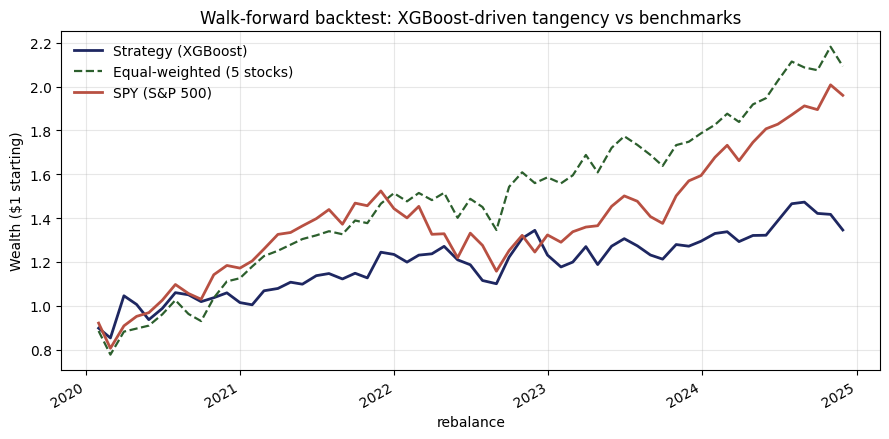

In [154]:
fig, ax = plt.subplots(figsize=(9, 4.5))
strat_wealth.plot(ax=ax, label=f"Strategy ({chosen_name})", linewidth=2,   color="#1E2761")
eq_wealth.plot(ax=ax,    label="Equal-weighted (5 stocks)", linewidth=1.6, color="#2C5F2D", linestyle="--")
spy_wealth.plot(ax=ax,   label="SPY (S&P 500)",             linewidth=2,   color="#B85042")
ax.set_ylabel("Wealth ($1 starting)")
ax.set_title(f"Walk-forward backtest: {chosen_name}-driven tangency vs benchmarks")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


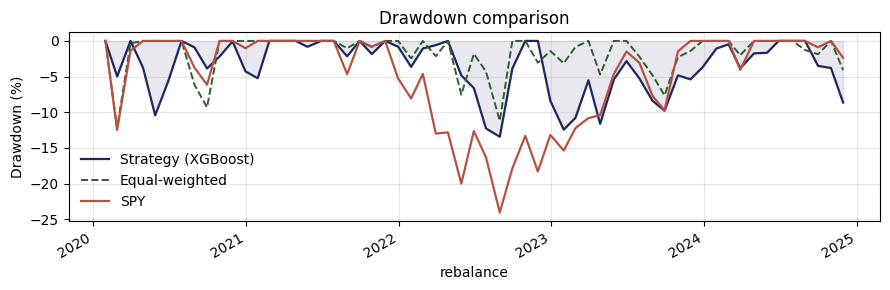

In [155]:
fig, ax = plt.subplots(figsize=(9, 3))
strat_dd = strat_wealth / strat_wealth.cummax() - 1
eq_dd    = eq_wealth    / eq_wealth.cummax()    - 1
spy_dd   = spy_wealth   / spy_wealth.cummax()   - 1
(strat_dd * 100).plot(ax=ax, label=f"Strategy ({chosen_name})", linewidth=1.6, color="#1E2761")
(eq_dd * 100).plot(ax=ax,    label="Equal-weighted",            linewidth=1.4, color="#2C5F2D", linestyle="--")
(spy_dd * 100).plot(ax=ax,   label="SPY",                       linewidth=1.6, color="#B85042")
ax.fill_between(strat_dd.index, strat_dd*100, 0, alpha=0.10, color="#1E2761")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown comparison")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9.5 Weights drift over the backtest

How much does the optimal allocation move from month to month? Stable weights = the model's signal is consistent. Wildly oscillating weights = the model is reactive (or noisy).

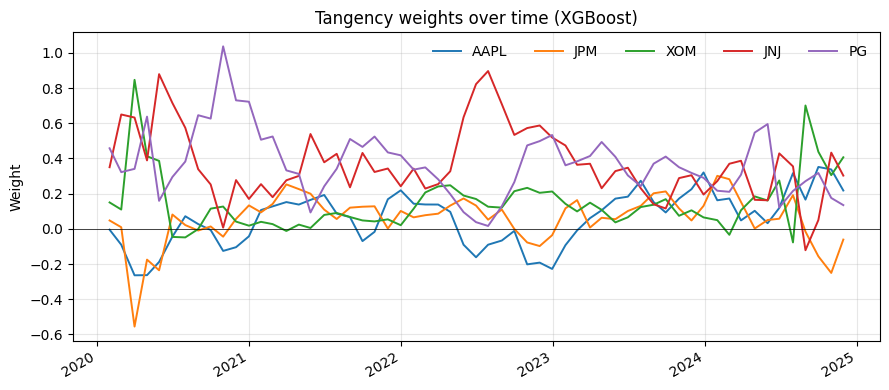


Weights summary across rebalances:
        mean     std     min     max
AAPL  0.0584  0.1531 -0.2641  0.3515
JPM   0.0577  0.1389 -0.5555  0.3010
XOM   0.1467  0.1646 -0.0773  0.8466
JNJ   0.3690  0.2035 -0.1215  0.8964
PG    0.3682  0.1868  0.0162  1.0368


In [156]:
fig, ax = plt.subplots(figsize=(9, 4))
weights_df.plot(ax=ax, linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Weight")
ax.set_title(f"Tangency weights over time ({chosen_name})")
ax.legend(frameon=False, ncol=len(port_tickers))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWeights summary across rebalances:")
print(weights_df.describe().T[["mean", "std", "min", "max"]].round(4))


---

# Appendix

## 10. Inspection of the chosen model

Diagnostic material that supports the report but isn't part of the main forecast → optimize pipeline. Run if you want to characterize the chosen model's behavior in detail.

### 10.1 Reattach predictions to (date, permno, ticker)

In [157]:
test_df = (
    fwt[(fwt["date"] > VAL_END) & (fwt["date"] <= DATA_END)]
      .dropna(subset=["y"])
      .query("in_universe")
      .sort_values(["date", "permno"])
      .copy()
)
test_df["y_pred"] = chosen_model.predict(test_df[ALL_COLS])
test_df["err"]    = test_df["y"] - test_df["y_pred"]

print(f"Test predictions ({chosen_name}): {len(test_df):,} rows")
test_df[["date", "permno", "ticker", "y_pred", "y", "err"]].head()

Test predictions (XGBoost): 58,850 rows


,date,permno,ticker,y_pred,y,err
934,2020-01-31,10026,JJSF,0.006803,-0.03147,-0.038273
3334,2020-01-31,10104,ORCL,0.006803,-0.058207,-0.06501
3634,2020-01-31,10107,MSFT,0.006803,-0.046492,-0.053295
4505,2020-01-31,10138,TROW,0.006803,-0.117429,-0.124232
4933,2020-01-31,10145,HON,0.006803,-0.059796,-0.066599


### 10.2 OOS R² broken down by month

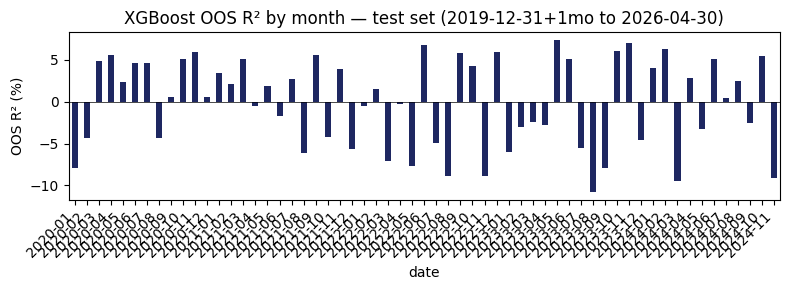

Mean monthly R²:    -0.081%
# months R² > 0:    32 / 59


In [158]:
monthly_r2 = (
    test_df.groupby("date")
           .apply(lambda d: oos_r2_zero_benchmark(d["y"].values, d["y_pred"].values))
           .rename("oos_r2")
)

fig, ax = plt.subplots(figsize=(8, 3))
(monthly_r2 * 100).plot(kind="bar", ax=ax, color="#1E2761")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("OOS R² (%)")
ax.set_title(f"{chosen_name} OOS R² by month — test set ({VAL_END}+1mo to {DATA_END})")
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_r2.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Mean monthly R²:    {monthly_r2.mean()*100:.3f}%")
print(f"# months R² > 0:    {(monthly_r2 > 0).sum()} / {len(monthly_r2)}")

### 10.3 Coefficient inspection (linear models only)

In [159]:
if hasattr(chosen_model, "coef_"):
    firm_coef_idx = [ALL_COLS.index(c) for c in FEATURE_COLS if c in ALL_COLS]
    coefs = pd.Series(chosen_model.coef_[firm_coef_idx],
                      index=[ALL_COLS[i] for i in firm_coef_idx])
    sign_check = pd.DataFrame({
        "coef":     coefs.round(5),
        "expected": pd.Series({k: v["expected_sign"] for k, v in FEATURE_DICT.items()}),
    })
    sign_check["actual"] = np.where(sign_check["coef"] > 0, "+",
                           np.where(sign_check["coef"] < 0, "\u2212", "0"))
    sign_check["match"] = (
        (sign_check["actual"] == sign_check["expected"])
        | (sign_check["expected"] == "?")
    )
    print(f"{chosen_name} coefficients (firm chars only) — sign-checked vs FEATURE_DICT:")
    print(sign_check)
elif hasattr(chosen_model, "feature_importances_"):
    imp = pd.Series(chosen_model.feature_importances_, index=ALL_COLS)
    print(f"{chosen_name} top-15 feature importances:")
    print(imp.sort_values(ascending=False).head(15).round(4))
else:
    print(f"{chosen_name} has no .coef_ or .feature_importances_ attribute.")

XGBoost top-15 feature importances:
age          0.1929
turnover     0.0875
profit       0.0868
vol_12       0.0797
ep           0.0681
mom_36_13    0.0642
beta         0.0540
sic_73       0.0524
sic_13       0.0500
mom_6_2      0.0488
mom_12_2     0.0389
sic_48       0.0363
mom_1        0.0213
sic_28       0.0205
ind_mom      0.0205
dtype: float32


### 10.4 Factor decomposition of ML predictions

For each portfolio stock, regress the time series of ML predictions on factor returns:

$$\hat{r}_{i,t+1} - r_{f,t+1} = \alpha_i + \beta_i \, \text{Mkt-RF}_{t+1} + \varepsilon_{i,t+1} \quad \text{(CAPM)}$$

$$\hat{r}_{i,t+1} - r_{f,t+1} = \alpha_i + \beta_{mkt,i} \, \text{Mkt-RF}_{t+1} + \beta_{smb,i} \, \text{SMB}_{t+1} + \beta_{hml,i} \, \text{HML}_{t+1} + \beta_{rmw,i} \, \text{RMW}_{t+1} + \beta_{cma,i} \, \text{CMA}_{t+1} + \varepsilon_{i,t+1} \quad \text{(FF5)}$$

$\beta$ is the implicit factor exposure the model is assigning; $\alpha$ is the model's predicted abnormal return.

In [160]:
test_with_factors = merge_with_factors(test_df, ff5)

decomp_rows = []
for ticker in portfolio.values():
    stock_data = (
        test_with_factors[test_with_factors["ticker"] == ticker]
          .sort_values("date")
          .dropna(subset=["Mkt-RF"])
    )
    if len(stock_data) < 6:
        decomp_rows.append({"ticker": ticker, "n_months": len(stock_data), "note": "insufficient data"})
        continue
    capm = fit_capm(stock_data["y_pred"].reset_index(drop=True),
                    stock_data["Mkt-RF"].reset_index(drop=True))
    ff5_res = fit_ff5(stock_data["y_pred"].reset_index(drop=True),
                      stock_data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True))
    decomp_rows.append({
        "company":    ticker_to_name[ticker],
        "ticker":     ticker,
        "n_months":   len(stock_data),
        "capm_alpha": capm["alpha"],
        "capm_beta":  capm["beta"],
        "capm_R2":    capm["r2"],
        "ff5_alpha":  ff5_res["alpha"],
        "ff5_b_mkt":  ff5_res["betas"]["Mkt-RF"],
        "ff5_b_smb":  ff5_res["betas"]["SMB"],
        "ff5_b_hml":  ff5_res["betas"]["HML"],
        "ff5_b_rmw":  ff5_res["betas"]["RMW"],
        "ff5_b_cma":  ff5_res["betas"]["CMA"],
        "ff5_R2":     ff5_res["r2"],
    })

decomp_ml = pd.DataFrame(decomp_rows).set_index("ticker")
print(f"Factor decomposition of {chosen_name} predictions:\n")
decomp_ml.round(4)

Factor decomposition of XGBoost predictions:



,company,n_months,capm_alpha,capm_beta,capm_R2,ff5_alpha,ff5_b_mkt,ff5_b_smb,ff5_b_hml,ff5_b_rmw,ff5_b_cma,ff5_R2
ticker,,,,,,,,,,,,
AAPL,Apple,59,0.0068,-0.0,-inf,0.0068,0.0,0.0,0.0,0.0,-0.0,-inf
JPM,JPMorgan Chase,59,0.0068,-0.0,-inf,0.0068,0.0,0.0,0.0,0.0,-0.0,-inf
XOM,Exxon Mobil,59,0.0068,-0.0,-inf,0.0068,0.0,0.0,0.0,0.0,-0.0,-inf
JNJ,Johnson & Johnson,59,0.0068,-0.0,-inf,0.0068,0.0,0.0,0.0,0.0,-0.0,-inf
PG,Procter & Gamble,59,0.0068,-0.0,-inf,0.0068,0.0,0.0,0.0,0.0,-0.0,-inf


### 10.5 Compare with realized-return factor decomposition

In [161]:
decomp_rows_real = []
for ticker in portfolio.values():
    stock_data = (
        test_with_factors[test_with_factors["ticker"] == ticker]
          .sort_values("date")
          .dropna(subset=["Mkt-RF"])
    )
    if len(stock_data) < 6:
        continue
    capm = fit_capm(stock_data["y"].reset_index(drop=True),
                    stock_data["Mkt-RF"].reset_index(drop=True))
    ff5_res = fit_ff5(stock_data["y"].reset_index(drop=True),
                      stock_data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True))
    decomp_rows_real.append({
        "company":    ticker_to_name[ticker],
        "ticker":     ticker,
        "capm_alpha": capm["alpha"],
        "capm_beta":  capm["beta"],
        "capm_R2":    capm["r2"],
        "ff5_alpha":  ff5_res["alpha"],
        "ff5_b_mkt":  ff5_res["betas"]["Mkt-RF"],
        "ff5_R2":     ff5_res["r2"],
    })

if decomp_rows_real:
    decomp_real = pd.DataFrame(decomp_rows_real).set_index("ticker")
    print("Factor decomposition of REALIZED returns:\n")
    print(decomp_real.round(4))
else:
    print("No stocks have ≥6 months of test data — extend DATA_END or check date alignment.")

Factor decomposition of REALIZED returns:

                  company  capm_alpha  capm_beta  capm_R2  ff5_alpha  ff5_b_mkt  ff5_R2
ticker                                                                                 
AAPL                Apple      0.0236    -0.1367   0.0078     0.0218    -0.2835  0.1007
JPM        JPMorgan Chase      0.0143    -0.0604   0.0017     0.0156    -0.1190  0.0163
XOM           Exxon Mobil      0.0208    -0.4039   0.0503     0.0203    -0.4276  0.1174
JNJ     Johnson & Johnson      0.0023    -0.1007   0.0117     0.0013    -0.0757  0.0826
PG       Procter & Gamble      0.0061     0.0276   0.0008     0.0043    -0.0148  0.0322


---

## 11. Export artifacts for the web app

Saves the trained production model + key dataframes into a single pickle file. The Streamlit app (`app.py`) loads this at startup so it can serve forecasts/optimizations instantly — no WRDS pulls, no retraining at app launch.

**Run order:** after §9 finishes. Then in a terminal: `streamlit run app.py`.

In [162]:
import joblib

# Latest feature snapshot — one row per ticker, most recent date in universe
latest_features_export = (
    features[features["in_universe"]]
      .sort_values(["ticker", "date"])
      .groupby("ticker")
      .tail(1)
      [["ticker", "permno", "comnam", "date"] + ALL_COLS]
      .reset_index(drop=True)
)

artifacts = {
    "chosen_name":       chosen_name,
    "model_prod":        model_prod,
    "all_cols":          ALL_COLS,
    "feature_cols":      FEATURE_COLS,
    "latest_features":   latest_features_export,
    "comparison_single": comparison,       # §6.4 single-split comparison
    "rolling_summary":   rolling_summary,  # §6.6 walk-forward summary
    "yearly_r2":         yearly,           # §6.6 per-year R² table
    "backtest":          bt_df,            # §9 strategy backtest
    "backtest_stats":    stats,            # §9.4 perf summary table
    "demo_portfolio":    portfolio,        # the 5-stock dict
    "data_start":        DATA_START,
    "data_end":          DATA_END,
}

art_path = CONFIG.cache_dir / "app_artifacts.pkl"
art_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifacts, art_path)

import os
size_mb = os.path.getsize(art_path) / (1024 * 1024)
print(f"Saved {art_path}  ({size_mb:.1f} MB)")
print(f"\nNow run, from the project folder:")
print(f"   streamlit run app.py")


Saved cache/app_artifacts.pkl  (3.7 MB)

Now run, from the project folder:
   streamlit run app.py
